In [47]:
import pandas as pd

from pathlib import Path

In [48]:
# Directory containing this Python file
BASE_DIR = Path.cwd()

# Data file relative to this script
DATA_DIR = BASE_DIR / "recipe_matching_llm_100"

In [49]:
df = pd.read_csv(DATA_DIR / "ingredient_matches_llm.csv")
print(df.index.size)
df.head()

200


,run_id,run_name,model,recipe_id,ingredient_idx,ingredient,name,preparation,dequantified,unit,...,relevant_steps,prompt_tokens,completion_tokens,total_tokens,price_estimate_usd,ts,ts_year,ts_month,ts_date,ts_time
0,309415c0b79440a883e37a17fd025fa4,gpt-4o-mini__seed42__20260607T034842Z,gpt-4o-mini,27257,0,2 Tbsp. lemon juice,lemon juice,NaN,Tbsp. lemon juice,Tbsps,...,NaN,889,29,918,0.000151,2026-06-07 03:49:18.087835+00:00,2026,6,7,03:49:18
1,309415c0b79440a883e37a17fd025fa4,gpt-4o-mini__seed42__20260607T034842Z,gpt-4o-mini,27257,1,1/2 tsp. dried thyme,dried thyme,NaN,tsp. dried thyme,tsps,...,NaN,861,30,891,0.000147,2026-06-07 03:49:18.154123+00:00,2026,6,7,03:49:18
2,309415c0b79440a883e37a17fd025fa4,gpt-4o-mini__seed42__20260607T034842Z,gpt-4o-mini,104902,0,8 ears fresh corn (or frozen),fresh corn,NaN,ears fresh corn (or frozen),ears,...,"Cook corn in water to cover 5 to 7 minutes or until tender. Drain, cool and set aside. | When co...",934,31,965,0.000159,2026-06-07 03:49:18.179759+00:00,2026,6,7,03:49:18
3,309415c0b79440a883e37a17fd025fa4,gpt-4o-mini__seed42__20260607T034842Z,gpt-4o-mini,104902,1,1/2 c. vegetable oil,vegetable oil,NaN,c. vegetable oil,c,...,"In large bowl, mix oil, vinegar, lemon juice, parsley, sugar, salt, basil and cayenne pepper. | ...",934,31,965,0.000159,2026-06-07 03:49:18.187622+00:00,2026,6,7,03:49:18
4,309415c0b79440a883e37a17fd025fa4,gpt-4o-mini__seed42__20260607T034842Z,gpt-4o-mini,27257,5,1/2 c. dry white wine,dry white wine,NaN,c. dry white wine,c,...,NaN,915,29,944,0.000155,2026-06-07 03:49:18.187746+00:00,2026,6,7,03:49:18


In [50]:
pd.set_option('display.max_rows', 500)

Text(0.5, 0, 'LLM Certainty')

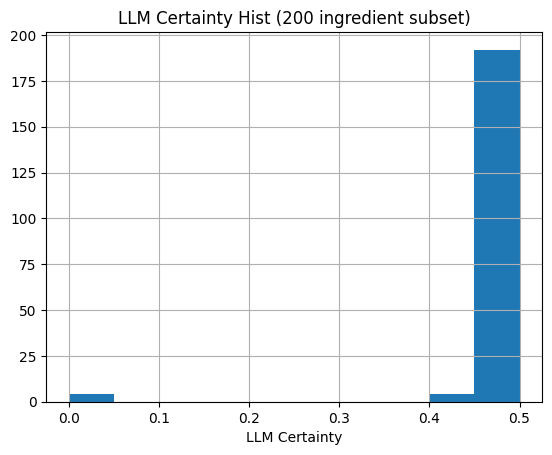

In [ ]:
import matplotlib.pyplot as plt
(df['llm_certainty']).hist()
plt.title("LLM Certainty Hist (200 ingredient subset)")
plt.xlabel("LLM Certainty")

<Axes: >

,ingredient,name,preparation,dequantified,llm_description,llm_certainty,llm_rationale
96,1 bottle almond extract,almond extract,NaN,bottle almond extract,NaN,0.00,No candidates match almond extract specifically.
95,4 pkg. lemon jello,"pkg., lemon jello",NaN,pkg. lemon jello,NaN,0.00,No candidates match lemon jello specifically.
179,4 Tbsp. Crisco,Crisco,NaN,Tbsp. Crisco,NaN,0.00,"No candidates match Crisco, which is a shortening."
145,1 pkg. Sure-Jell,pkg. Sure-Jell,NaN,pkg. Sure-Jell,NaN,0.00,"No candidates match Sure-Jell, a pectin product for jellies."
146,"1 whole chicken, cut up",whole chicken,cut up,"whole chicken, cut up","CHICKEN READY, ONE WHOLE CHICKEN",0.80,"Best match for a whole chicken, cut up."
143,12 field corn cobs (red) after dried corn husked,field corn cobs (red),NaN,field corn cobs (red) after dried corn husked,"Corn, dried (Navajo)",0.80,Dried corn cobs match best with dried corn entry.
156,"1 red and green pepper, sliced into strips","red pepper, green pepper",sliced into strips,"red and green pepper, sliced into strips",PEPPER STRIP,0.80,Pepper strip matches both red and green peppers sliced into strips.
180,6 Tbsp. sour milk (1/2 c.),sour milk,NaN,Tbsp. sour milk (1/2 c.),"Cream, sour, cultured",0.80,"Sour milk is closely related to sour cream, which is cultured."
100,1 pkg. frozen peas,pkg. frozen peas,NaN,pkg. frozen peas,PEAS,0.90,Best match for frozen peas with high lexical and semantic scores.
126,3 tsp. baking powder,baking powder,NaN,tsp. baking powder,BAKING POWDER,0.90,"Best match for generic baking powder, high L and S scores."


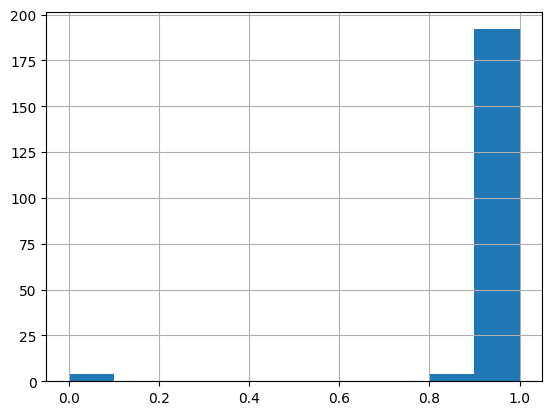

In [56]:
short_cols = ['ingredient', 'name', 'preparation', 'dequantified', 'llm_description','llm_certainty', 'llm_rationale']

display(df['llm_certainty'].hist())
display(df[short_cols].sort_values(by='llm_certainty', ascending=True))

In [57]:
pd.set_option('display.max_colwidth', 100)

In [58]:
df_cand = pd.read_csv(DATA_DIR / "ingredient_candidates_top10.csv")

CERTAINTY_THRESHOLD = 0.5
KEY = ['recipe_id', 'ingredient_idx']  # an ingredient is unique only on this pair

# Ingredient-side context for the low-confidence picks
context_cols = ['ingredient', 'name', 'llm_description', 'llm_certainty', 'llm_rationale']
low_certainty = df.loc[df['llm_certainty'] < CERTAINTY_THRESHOLD, KEY + context_cols]

# Candidate rows for those ingredients, with the ingredient context attached
problem_candidates = (
    low_certainty.merge(df_cand, on=KEY, how='inner')
                 .sort_values(KEY + ['rank'])
                 .reset_index(drop=True)
)

# Drop id/filler columns that don't describe the comparison, metrics, or rationale
filler = ['run_id', 'recipe_id', 'ingredient_idx', 'fdc_id', 'data_type', 'ts']
problem_candidates = problem_candidates.drop(columns=filler, errors='ignore')

print(f"{len(low_certainty)} low-certainty ingredients -> {len(problem_candidates)} candidate rows")
problem_candidates






4 low-certainty ingredients -> 40 candidate rows


,ingredient,name,llm_description,llm_certainty,llm_rationale,rank,description,lexical_dequant,dequant_sem,retrieval_score,staged_final_score,staged_base_score,staged_prep_score,in_llm_prompt,is_staged_top1,is_llm_pick
0,4 pkg. lemon jello,"pkg., lemon jello",NaN,0.0,No candidates match lemon jello specifically.,1,LEMON,0.5833,0.6335,0.6109,0.5597,0.5933,0.4962,True,True,False
1,4 pkg. lemon jello,"pkg., lemon jello",NaN,0.0,No candidates match lemon jello specifically.,2,LEMONS,0.5833,0.5968,0.5907,0.5553,0.5865,0.4962,True,False,False
2,4 pkg. lemon jello,"pkg., lemon jello",NaN,0.0,No candidates match lemon jello specifically.,3,LEMON PIE,0.3750,0.6103,0.5044,0.4492,0.4233,0.4962,True,False,False
3,4 pkg. lemon jello,"pkg., lemon jello",NaN,0.0,No candidates match lemon jello specifically.,4,"LEMON PIE, LEMON",0.3740,0.6075,0.5024,0.4490,0.4230,0.4962,True,False,False
4,4 pkg. lemon jello,"pkg., lemon jello",NaN,0.0,No candidates match lemon jello specifically.,5,GLAZED LEMON SLICES,0.3853,0.5752,0.4897,0.4470,0.4200,0.4962,True,False,False
5,4 pkg. lemon jello,"pkg., lemon jello",NaN,0.0,No candidates match lemon jello specifically.,6,LEMON CANDY,0.3731,0.5806,0.4872,0.4442,0.4157,0.4962,True,False,False
6,4 pkg. lemon jello,"pkg., lemon jello",NaN,0.0,No candidates match lemon jello specifically.,7,LEMON ZEST,0.3740,0.5758,0.4850,0.4440,0.4154,0.4962,True,False,False
7,4 pkg. lemon jello,"pkg., lemon jello",NaN,0.0,No candidates match lemon jello specifically.,8,"LEMON BARS, LEMON",0.3731,0.5716,0.4823,0.4437,0.4148,0.4962,True,False,False
8,4 pkg. lemon jello,"pkg., lemon jello",NaN,0.0,No candidates match lemon jello specifically.,9,"LEMON SODA, LEMON",0.3731,0.5678,0.4802,0.4432,0.4141,0.4962,True,False,False
9,4 pkg. lemon jello,"pkg., lemon jello",NaN,0.0,No candidates match lemon jello specifically.,10,"LEMON PEPPER, LEMON",0.3714,0.5667,0.4788,0.4424,0.4128,0.4962,True,False,False
